# Daily product-store demand classification with ADI and CV^2

This notebook compares two ways of constructing daily product-store time series before classifying demand into **smooth**, **erratic**, **intermittent**, and **lumpy** patterns.

The goal is to test how much the daily classification depends on the zero-sales assumption.


This setup cell imports the required libraries, defines the product-store grain, sets the demand column and ADI/CV2 thresholds, and resolves the two processed daily datasets used in the comparison.


In [17]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
MIN_DEMAND_DAYS = 10
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

CLASS_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
CLASS_PALETTE = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

APPROACH_LABELS = {
    "broad_active_window": "Broad active window",
    "availability_proxy_7d": "Availability proxy (7d receipt)",
}

DATASET_CANDIDATES = {
    "broad_active_window": [
        Path("../../data/processed/transactions_dst_over_days"),
        Path("data/processed/transactions_dst_over_days"),
    ],
    "availability_proxy_7d": [
        Path("../../data/processed/transactions_dst_over_days_availability_proxy"),
        Path("data/processed/transactions_dst_over_days_availability_proxy"),
    ],
}


def resolve_data_dir(candidates):
    data_dir = next((path for path in candidates if path.exists()), None)
    if data_dir is None:
        searched = ", ".join(str(path) for path in candidates)
        raise FileNotFoundError(f"Could not find any of: {searched}")
    parquet_files = sorted(data_dir.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {data_dir}")
    return data_dir


DATA_DIRS = {
    approach: resolve_data_dir(candidates)
    for approach, candidates in DATASET_CANDIDATES.items()
}

for approach, data_dir in DATA_DIRS.items():
    print(f"{APPROACH_LABELS[approach]}: {data_dir}")
print(f"Classifying demand series at grain: {', '.join(GROUP_COLS)}")


Broad active window: ..\..\data\processed\transactions_dst_over_days
Availability proxy (7d receipt): ..\..\data\processed\transactions_dst_over_days_availability_proxy
Classifying demand series at grain: ARTIKEL_ID, MARKT_ID


This early coverage check shows how many broad daily product-store series have at least one positive goods-receipt record in the availability-proxy data. It reports both the full broad series universe and the subset that meets the notebook's minimum demand-day threshold. Here, replenishment coverage means `PAIR_POSITIVE_REPLENISHMENT_DAYS > 0` for the same `ARTIKEL_ID` x `MARKT_ID` series.


In [18]:
coverage_con = duckdb.connect()
coverage_con.execute("PRAGMA threads=4")

broad_glob = str(DATA_DIRS["broad_active_window"] / "*.parquet")
proxy_glob = str(DATA_DIRS["availability_proxy_7d"] / "*.parquet")

proxy_columns = {
    row[0]
    for row in coverage_con.execute(
        "DESCRIBE SELECT * FROM read_parquet(?)", [proxy_glob]
    ).fetchall()
}
required_proxy_columns = {
    "ARTIKEL_ID",
    "MARKT_ID",
    "PAIR_POSITIVE_REPLENISHMENT_DAYS",
    "PAIR_POSITIVE_WE_MENGE_VKE",
}
missing_proxy_columns = sorted(required_proxy_columns - proxy_columns)
if missing_proxy_columns:
    raise ValueError(
        "Availability-proxy data is missing replenishment coverage columns: "
        f"{missing_proxy_columns}"
    )

replenishment_coverage = coverage_con.execute(
    """
    WITH broad_series AS (
        SELECT
            ARTIKEL_ID,
            MARKT_ID,
            SUM(
                CASE
                    WHEN COALESCE(ABVERKAUFTE_MENGE_KG, 0.0) > 0 THEN 1
                    ELSE 0
                END
            ) AS broad_demand_days
        FROM read_parquet(?)
        GROUP BY ARTIKEL_ID, MARKT_ID
    ), proxy_series AS (
        SELECT
            ARTIKEL_ID,
            MARKT_ID,
            MAX(COALESCE(PAIR_POSITIVE_REPLENISHMENT_DAYS, 0))
                AS positive_replenishment_days,
            MAX(COALESCE(PAIR_POSITIVE_WE_MENGE_VKE, 0.0))
                AS positive_replenishment_vke
        FROM read_parquet(?)
        GROUP BY ARTIKEL_ID, MARKT_ID
    )
    SELECT
        COUNT(*)::INTEGER AS broad_daily_series,
        SUM(
            CASE
                WHEN COALESCE(p.positive_replenishment_days, 0) > 0 THEN 1
                ELSE 0
            END
        )::INTEGER AS series_with_positive_replenishment,
        SUM(
            CASE
                WHEN COALESCE(p.positive_replenishment_days, 0) = 0 THEN 1
                ELSE 0
            END
        )::INTEGER AS series_without_positive_replenishment,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN COALESCE(p.positive_replenishment_days, 0) > 0 THEN 1
                    ELSE 0
                END
            ) / NULLIF(COUNT(*), 0),
            1
        ) AS replenishment_coverage_pct,
        SUM(
            CASE
                WHEN b.broad_demand_days >= ? THEN 1
                ELSE 0
            END
        )::INTEGER AS eligible_broad_daily_series,
        SUM(
            CASE
                WHEN b.broad_demand_days >= ?
                    AND COALESCE(p.positive_replenishment_days, 0) > 0
                    THEN 1
                ELSE 0
            END
        )::INTEGER AS eligible_series_with_positive_replenishment,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN b.broad_demand_days >= ?
                        AND COALESCE(p.positive_replenishment_days, 0) > 0
                        THEN 1
                    ELSE 0
                END
            ) / NULLIF(
                SUM(
                    CASE
                        WHEN b.broad_demand_days >= ? THEN 1
                        ELSE 0
                    END
                ),
                0
            ),
            1
        ) AS eligible_replenishment_coverage_pct,
        SUM(COALESCE(p.positive_replenishment_days, 0))::INTEGER
            AS positive_replenishment_days,
        ROUND(SUM(COALESCE(p.positive_replenishment_vke, 0.0)), 1)
            AS positive_replenishment_vke
    FROM broad_series b
    LEFT JOIN proxy_series p
        USING (ARTIKEL_ID, MARKT_ID)
    """,
    [
        broad_glob,
        proxy_glob,
        MIN_DEMAND_DAYS,
        MIN_DEMAND_DAYS,
        MIN_DEMAND_DAYS,
        MIN_DEMAND_DAYS,
    ],
).fetchdf()

replenishment_coverage


,broad_daily_series,series_with_positive_replenishment,series_without_positive_replenishment,replenishment_coverage_pct,eligible_broad_daily_series,eligible_series_with_positive_replenishment,eligible_replenishment_coverage_pct,positive_replenishment_days,positive_replenishment_vke
0,3667,3583,84,97.7,2347,2326,99.1,79602,384058.8


## Method

For each product-store demand series:

- **ADI** is `active_days / demand_days`, where demand days have sold quantity above zero.
- **CV^2** is `variance(non-zero demand) / mean(non-zero demand)^2`.
- **Smooth**: `ADI < 1.32` and `CV^2 < 0.49`.
- **Erratic**: `ADI < 1.32` and `CV^2 >= 0.49`.
- **Intermittent**: `ADI >= 1.32` and `CV^2 < 0.49`.
- **Lumpy**: `ADI >= 1.32` and `CV^2 >= 0.49`.

The comparison uses two daily datasets:

- **Broad active window**: every open day between the first and last observed sale is treated as active; missing sales are filled with zero.
- **Availability proxy**: positive sale days are active, and missing sales are filled with zero only when a positive goods receipt occurred within the previous 7 days.

The proxy still does not prove true customer demand. It narrows the zero-sales assumption to days with replenishment evidence.


This cell computes one ADI/CV2 metric row per `ARTIKEL_ID` x `MARKT_ID` series for each approach. It then assigns each series to `smooth`, `erratic`, `intermittent`, or `lumpy` demand using the configured cutoffs.


In [19]:
con = duckdb.connect()
con.execute("PRAGMA threads=4")

group_cols_sql = ", ".join(GROUP_COLS)
daily_group_cols_sql = ", ".join([*GROUP_COLS, "sale_date"])


def compute_series_metrics(data_dir, approach):
    parquet_glob = str(data_dir / "*.parquet")
    query = f"""
    WITH raw AS (
        SELECT
            {group_cols_sql},
            CAST(DATE AS DATE) AS sale_date,
            CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand
        FROM read_parquet(?)
    ), daily AS (
        SELECT
            {daily_group_cols_sql},
            SUM(demand) AS demand
        FROM raw
        GROUP BY {daily_group_cols_sql}
    ), series AS (
        SELECT
            {group_cols_sql},
            COUNT(*) AS active_days,
            SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_days,
            SUM(demand) AS series_total_demand,
            AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
            VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
            MIN(sale_date) AS first_active_day,
            MAX(sale_date) AS last_active_day
        FROM daily
        GROUP BY {group_cols_sql}
    )
    SELECT
        *,
        active_days - demand_days AS zero_days,
        1 - demand_days / NULLIF(active_days, 0) AS zero_day_share,
        active_days / NULLIF(demand_days, 0) AS ADI,
        CASE
            WHEN demand_days > 1 AND mean_nonzero_demand > 0
                THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
            WHEN demand_days = 1 THEN 0.0
            ELSE NULL
        END AS CV2
    FROM series
    WHERE demand_days > 0
    """
    metrics = con.execute(query, [parquet_glob]).fetchdf()
    metrics["approach"] = approach
    return metrics


def classify_demand(metrics):
    conditions = [
        (metrics["ADI"] < ADI_CUTOFF) & (metrics["CV2"] < CV2_CUTOFF),
        (metrics["ADI"] < ADI_CUTOFF) & (metrics["CV2"] >= CV2_CUTOFF),
        (metrics["ADI"] >= ADI_CUTOFF) & (metrics["CV2"] < CV2_CUTOFF),
        (metrics["ADI"] >= ADI_CUTOFF) & (metrics["CV2"] >= CV2_CUTOFF),
    ]
    classified = metrics.assign(
        demand_class=np.select(conditions, CLASS_ORDER, default="unclassified")
    )
    classified = classified[classified["demand_class"].isin(CLASS_ORDER)].copy()
    classified = classified[classified["demand_days"] >= MIN_DEMAND_DAYS].copy()
    classified["demand_class"] = pd.Categorical(
        classified["demand_class"], categories=CLASS_ORDER, ordered=True
    )
    classified["approach_label"] = classified["approach"].map(APPROACH_LABELS)
    return classified


series_metrics = pd.concat(
    [compute_series_metrics(data_dir, approach) for approach, data_dir in DATA_DIRS.items()],
    ignore_index=True,
)
series_classification = classify_demand(series_metrics)
series_classification.head()


,ARTIKEL_ID,MARKT_ID,active_days,demand_days,series_total_demand,mean_nonzero_demand,var_nonzero_demand,first_active_day,last_active_day,zero_days,zero_day_share,ADI,CV2,approach,demand_class,approach_label
0,1382768,1100054,367,78.0,36.877,0.472782,0.261423,2025-04-22,2026-07-08,289.0,0.787466,4.705128,1.169559,broad_active_window,lumpy,Broad active window
1,1382768,1300020,367,128.0,116.261,0.908289,0.961563,2025-04-24,2026-07-10,239.0,0.651226,2.867188,1.165547,broad_active_window,lumpy,Broad active window
2,1382768,1100053,362,140.0,43.882,0.313443,0.060717,2025-04-28,2026-07-08,222.0,0.613260,2.585714,0.618011,broad_active_window,lumpy,Broad active window
3,1382768,1100044,368,224.0,111.798,0.499098,0.174991,2025-04-22,2026-07-09,144.0,0.391304,1.642857,0.702497,broad_active_window,lumpy,Broad active window
4,1382767,1100031,174,121.0,51.186,0.423025,0.063473,2025-05-07,2025-11-29,53.0,0.304598,1.438017,0.354696,broad_active_window,intermittent,Broad active window


This summary compares the two daily construction approaches at a high level: number of series, products, stores, active days, demand days, zero days, median ADI/CV2, and zero-day shares.


In [20]:
overall_summary = (
    series_classification
    .groupby("approach_label", observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        products=("ARTIKEL_ID", "nunique"),
        stores=("MARKT_ID", "nunique"),
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        zero_days=("zero_days", "sum"),
        median_zero_day_share=("zero_day_share", "median"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
    )
)
overall_summary["zero_day_share_%"] = (
    100 * overall_summary["zero_days"] / overall_summary["active_days"]
).round(1)
overall_summary["median_zero_day_share_%"] = (100 * overall_summary["median_zero_day_share"]).round(1)
overall_summary[["median_ADI", "median_CV2"]] = overall_summary[["median_ADI", "median_CV2"]].round(2)
overall_summary.drop(columns="median_zero_day_share")


,series,products,stores,active_days,demand_days,zero_days,median_ADI,median_CV2,zero_day_share_%,median_zero_day_share_%
approach_label,,,,,,,,,,
Availability proxy (7d receipt),2347,37,105,379263,202738.0,176525.0,2.09,0.45,46.5,52.2
Broad active window,2347,37,105,503546,202738.0,300808.0,3.00,0.45,59.7,66.7


This table aggregates the classified series by approach and demand class. It shows how many series fall into each class and how sparse or variable those classes are on average.


In [21]:
class_summary = (
    series_classification
    .groupby(["approach", "approach_label", "demand_class"], observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        products=("ARTIKEL_ID", "nunique"),
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
        median_zero_day_share=("zero_day_share", "median"),
    )
    .reset_index()
)
class_summary["series_share"] = class_summary["series"] / class_summary.groupby("approach")["series"].transform("sum")

class_summary_display = class_summary.copy()
class_summary_display["series_share_%"] = (100 * class_summary_display["series_share"]).round(1)
class_summary_display["median_zero_day_share_%"] = (100 * class_summary_display["median_zero_day_share"]).round(1)
class_summary_display[["median_ADI", "median_CV2"]] = class_summary_display[["median_ADI", "median_CV2"]].round(2)
class_summary_display = class_summary_display[
    [
        "approach_label", "demand_class", "series", "products", "active_days",
        "demand_days", "series_share_%", "median_zero_day_share_%", "median_ADI", "median_CV2",
    ]
].sort_values(["approach_label", "demand_class"])
class_summary_display


,approach_label,demand_class,series,products,active_days,demand_days,series_share_%,median_zero_day_share_%,median_ADI,median_CV2
0,Availability proxy (7d receipt),smooth,156,16,39252,33268.0,6.6,15.1,1.18,0.41
1,Availability proxy (7d receipt),erratic,138,21,33473,28055.0,5.9,16.7,1.20,0.60
2,Availability proxy (7d receipt),intermittent,1194,35,173581,72812.0,50.9,62.6,2.67,0.33
3,Availability proxy (7d receipt),lumpy,859,28,132957,68603.0,36.6,50.0,2.00,0.60
4,Broad active window,smooth,110,14,30831,26290.0,4.7,14.1,1.16,0.42
5,Broad active window,erratic,78,16,20616,17019.0,3.3,17.8,1.22,0.57
6,Broad active window,intermittent,1240,35,237857,79790.0,52.8,73.4,3.76,0.34
7,Broad active window,lumpy,919,30,214242,79639.0,39.2,63.5,2.74,0.60


This compact table focuses on the availability-proxy data and translates the median ADI/CV2 values into the practical meaning of each demand class.


In [22]:
class_interpretations = {
    "smooth": "frequent demand, stable quantity",
    "erratic": "frequent demand, variable quantity",
    "intermittent": "sparse demand, stable quantity",
    "lumpy": "sparse demand, variable quantity",
}

proxy_class_interpretation_table = (
    class_summary[class_summary["approach"].eq("availability_proxy_7d")]
    .set_index("demand_class")
    .reindex(CLASS_ORDER)
    .reset_index()[["demand_class", "median_ADI", "median_CV2"]]
)
proxy_class_interpretation_table["interpretation"] = (
    proxy_class_interpretation_table["demand_class"].map(class_interpretations)
)
proxy_class_interpretation_table[["median_ADI", "median_CV2"]] = (
    proxy_class_interpretation_table[["median_ADI", "median_CV2"]].round(2)
)

proxy_class_interpretation_table


,demand_class,median_ADI,median_CV2,interpretation
0,smooth,1.18,0.41,"frequent demand, stable quantity"
1,erratic,1.20,0.60,"frequent demand, variable quantity"
2,intermittent,2.67,0.33,"sparse demand, stable quantity"
3,lumpy,2.00,0.60,"sparse demand, variable quantity"


This plot visualizes the demand-class shares for the broad zero-filled data and the replenishment-based availability proxy.


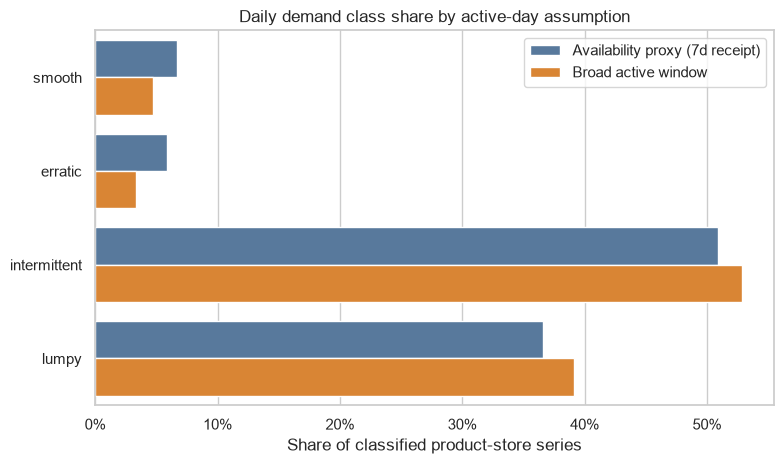

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.8))

sns.barplot(
    data=class_summary,
    y="demand_class",
    x="series_share",
    order=CLASS_ORDER,
    hue="approach_label",
    palette=["#4c78a8", "#f58518"],
    ax=ax,
)

ax.set_title("Daily demand class share by active-day assumption")
ax.set_xlabel("Share of classified product-store series")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(title="")

plt.tight_layout()


This table groups `smooth` and `erratic` as regular demand, and `intermittent` and `lumpy` as sparse demand, so the two approaches can be compared with one percentage split.


In [24]:
regular_sparse_share_table = (
    class_summary
    .assign(
        demand_frequency=np.where(
            class_summary["demand_class"].isin(["smooth", "erratic"]),
            "regular_demand_%",
            "sparse_demand_%",
        )
    )
    .groupby(["approach_label", "demand_frequency"], observed=True)["series_share"]
    .sum()
    .mul(100)
    .round(1)
    .unstack(fill_value=0)
    .reindex(columns=["regular_demand_%", "sparse_demand_%"])
)

regular_sparse_share_table


demand_frequency,regular_demand_%,sparse_demand_%
approach_label,,
Availability proxy (7d receipt),12.5,87.5
Broad active window,8.0,92.0


This transition matrix compares the class assigned to the same product-store series under both approaches. It shows which labels change after replacing broad zero-filling with the availability proxy.


In [25]:
broad = (
    series_classification[series_classification["approach"].eq("broad_active_window")]
    .set_index(GROUP_COLS)
)
proxy = (
    series_classification[series_classification["approach"].eq("availability_proxy_7d")]
    .set_index(GROUP_COLS)
)
common = broad.join(proxy, how="inner", lsuffix="_broad", rsuffix="_proxy")

transition = pd.crosstab(
    common["demand_class_broad"],
    common["demand_class_proxy"],
    rownames=["Broad active window"],
    colnames=["Availability proxy"],
).reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)

impact = common.assign(
    active_days_delta=common["active_days_proxy"] - common["active_days_broad"],
    zero_days_delta=common["zero_days_proxy"] - common["zero_days_broad"],
    ADI_delta=common["ADI_proxy"] - common["ADI_broad"],
)

print(f"Common classified product-store series: {len(common):,}")
print(f"Series with changed demand class: {(common['demand_class_broad'] != common['demand_class_proxy']).sum():,}")
print(f"Total active-day change: {impact['active_days_delta'].sum():,.0f}")
print(f"Total zero-day change: {impact['zero_days_delta'].sum():,.0f}")
transition


Common classified product-store series: 2,347
Series with changed demand class: 160
Total active-day change: -124,283
Total zero-day change: -124,283


Availability proxy,smooth,erratic,intermittent,lumpy
Broad active window,,,,
smooth,102,0,8,0
erratic,0,59,0,19
intermittent,54,0,1186,0
lumpy,0,79,0,840


This table summarizes how active days, zero days, and ADI change when moving from the broad active window to the availability proxy for the same series.


In [26]:
delta_summary = (
    impact[["active_days_delta", "zero_days_delta", "ADI_delta"]]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    .round(2)
)
delta_summary


,active_days_delta,zero_days_delta,ADI_delta
0.10,-157.0,-157.0,-4.50
0.25,-87.0,-87.0,-2.04
0.50,-33.0,-33.0,-0.52
0.75,-6.0,-6.0,-0.05
0.90,10.0,10.0,0.18


This diagnostic table explains where rows in the availability-proxy dataset come from: positive-sale days, positive-sale days with recent replenishment, or zero-sale days supported by recent replenishment.


In [27]:
proxy_glob = str(DATA_DIRS["availability_proxy_7d"] / "*.parquet")
proxy_columns = {
    row[0]
    for row in con.execute(f"DESCRIBE SELECT * FROM read_parquet(?)", [proxy_glob]).fetchall()
}

if "AVAILABILITY_SOURCE" in proxy_columns:
    proxy_daily_summary = con.execute(
        """
        SELECT
            AVAILABILITY_SOURCE,
            COUNT(*) AS rows,
            COUNT(DISTINCT CAST(ARTIKEL_ID AS VARCHAR) || '|' || CAST(MARKT_ID AS VARCHAR)) AS series,
            SUM(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN 1 ELSE 0 END) AS positive_sale_days,
            AVG(DAYS_SINCE_REPLENISHMENT) AS mean_days_since_replenishment,
            approx_quantile(DAYS_SINCE_REPLENISHMENT, 0.50) AS median_days_since_replenishment
        FROM read_parquet(?)
        GROUP BY AVAILABILITY_SOURCE
        ORDER BY rows DESC
        """,
        [proxy_glob],
    ).fetchdf()
    proxy_daily_summary[["mean_days_since_replenishment", "median_days_since_replenishment"]] = (
        proxy_daily_summary[["mean_days_since_replenishment", "median_days_since_replenishment"]]
        .round(2)
    )
else:
    proxy_daily_summary = pd.DataFrame()

proxy_daily_summary


,AVAILABILITY_SOURCE,rows,series,positive_sale_days,mean_days_since_replenishment,median_days_since_replenishment
0,recent_replenishment_zero_sale,205700,3580,0.0,3.03,3
1,sale_and_recent_replenishment,161507,3443,161507.0,2.50,2
2,positive_sale,46777,2314,46777.0,NaN,<NA>


This table gives quartiles for ADI, CV2, active days, demand days, and zero-day share by approach and class. It helps identify whether class labels are driven by typical behavior or by borderline cases.


In [28]:
quantiles = (
    series_classification
    .groupby(["approach_label", "demand_class"], observed=True)[["ADI", "CV2", "active_days", "demand_days", "zero_day_share"]]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)
quantiles


ADI   CV2  active_days  \
approach_label                  demand_class                                 
Availability proxy (7d receipt) smooth       0.25  1.10  0.38       240.75   
                                             0.50  1.18  0.41       307.50   
                                             0.75  1.26  0.45       323.00   
                                erratic      0.25  1.13  0.53       215.50   
                                             0.50  1.20  0.60       276.00   
                                             0.75  1.26  0.72       310.50   
                                intermittent 0.25  1.88  0.23        70.00   
                                             0.50  2.67  0.33       134.00   
                                             0.75  4.00  0.42       180.00   
                                lumpy        0.25  1.64  0.54        95.00   
                                             0.50  2.00  0.60       147.00   
                                             0.75  2.54  0.70       197.00   
Broad active window             smooth       0.25  1.10  0.39       294.00   
                                             0.50  1.16  0.42       331.00   
                                             0.75  1.25  0.45       331.00   
                                erratic      0.25  1.18  0.53       209.25   
                                             0.50  1.22  0.57       294.00   
                                             0.75  1.27  0.62       331.00   
                                intermittent 0.25  2.20  0.24       128.00   
                                             0.50  3.76  0.34       157.00   
                                             0.75  6.36  0.42       292.00   
                                lumpy        0.25  1.90  0.54       137.50   
                                             0.50  2.74  0.60       244.00   
                                             0.75  4.98  0.71       326.00   

                                                   demand_days  zero_day_share  
approach_label                  demand_class                                    
Availability proxy (7d receipt) smooth       0.25       198.50            0.09  
                                             0.50       254.00            0.15  
                                             0.75       285.00            0.20  
                                erratic      0.25       179.50            0.12  
                                             0.50       224.00            0.17  
                                             0.75       263.00            0.20  
                                intermittent 0.25        18.00            0.47  
                                             0.50        36.00            0.63  
                                             0.75        77.00            0.75  
                                lumpy        0.25        37.00            0.39  
                                             0.50        68.00            0.50  
                                             0.75       103.00            0.61  
Broad active window             smooth       0.25       253.25            0.09  
                                             0.50       271.50            0.14  
                                             0.75       293.00            0.20  
                                erratic      0.25       166.25            0.15  
                                             0.50       256.00            0.18  
                                             0.75       277.75            0.22  
                                intermittent 0.25        18.00            0.55  
                                             0.50        37.00            0.73  
                                             0.75        82.00            0.84  
                                lumpy        0.25        37.50            0.47  
                                             0.50        72.00            0.63 

## Four representative proxy daily series

The four examples below use the availability-proxy daily dataset only. The selection follows the same idea as the weekly heterogeneity notebook: choose one product-store series from each ADI/CV2 demand class, prefer stable article metadata, and first try to keep the article fixed across different stores.


This cell selects four representative product-store series from the availability-proxy data, one per demand class. It prefers the same article across different stores so the plot highlights store-level heterogeneity for the same product.


In [29]:
PREFERRED_MIN_ACTIVE_DAYS = 120
proxy_approach = "availability_proxy_7d"
proxy_glob = str(DATA_DIRS[proxy_approach] / "*.parquet")

proxy_classification = series_classification[
    series_classification["approach"].eq(proxy_approach)
].copy()
proxy_classification["demand_class"] = proxy_classification["demand_class"].astype(str)

proxy_class_medians = (
    proxy_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2"]]
    .median()
    .rename(columns={"ADI": "class_median_ADI", "CV2": "class_median_CV2"})
)

proxy_metadata = con.execute(
    """
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        MIN(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
        MIN(ARTIKEL_INHALT) AS ARTIKEL_INHALT,
        MIN(VERKAUFSEINHEIT) AS VERKAUFSEINHEIT,
        MIN(GEWICHTSARTIKEL) AS GEWICHTSARTIKEL,
        COUNT(DISTINCT ARTIKEL_INHALT) AS n_artikel_inhalt,
        COUNT(DISTINCT VERKAUFSEINHEIT) AS n_verkaufseinheit,
        COUNT(DISTINCT GEWICHTSARTIKEL) AS n_gewichtsartikel
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID
    """,
    [proxy_glob],
).fetchdf()

proxy_examples_base = proxy_classification.merge(
    proxy_metadata, on=GROUP_COLS, how="left"
)

stable_metadata = (
    (proxy_examples_base["n_artikel_inhalt"] == 1)
    & (proxy_examples_base["n_verkaufseinheit"] == 1)
    & (proxy_examples_base["n_gewichtsartikel"] == 1)
)
proxy_metadata_candidates = proxy_examples_base[stable_metadata].copy()


def score_proxy_example_candidates(candidates):
    scored = candidates.merge(proxy_class_medians, on="demand_class", how="left").copy()
    scored["median_distance"] = (
        (scored["ADI"] - scored["class_median_ADI"]).abs()
        / scored["class_median_ADI"].replace(0, np.nan)
        + (scored["CV2"] - scored["class_median_CV2"]).abs()
        / scored["class_median_CV2"].replace(0, np.nan)
    )
    return scored


def has_all_proxy_classes(candidates):
    return set(candidates["demand_class"].dropna()).issuperset(CLASS_ORDER)


def select_same_proxy_article(candidates):
    if candidates.empty or not has_all_proxy_classes(candidates):
        return pd.DataFrame()

    scored = score_proxy_example_candidates(candidates)
    best_per_article_class = (
        scored
        .sort_values(
            ["ARTIKEL_ID", "demand_class", "median_distance", "active_days"],
            ascending=[True, True, True, False],
        )
        .groupby(["ARTIKEL_ID", "demand_class"], observed=True)
        .head(1)
    )

    article_scores = (
        best_per_article_class
        .groupby("ARTIKEL_ID", observed=True)
        .agg(
            n_classes=("demand_class", "nunique"),
            total_distance=("median_distance", "sum"),
            median_active_days=("active_days", "median"),
            ARTIKEL_BEZ=("ARTIKEL_BEZ", "first"),
            ARTIKEL_INHALT=("ARTIKEL_INHALT", "first"),
        )
        .loc[lambda df: df["n_classes"].eq(len(CLASS_ORDER))]
        .sort_values(["total_distance", "median_active_days"], ascending=[True, False])
    )

    if article_scores.empty:
        return pd.DataFrame()

    selected_article_id = article_scores.index[0]
    return (
        best_per_article_class[best_per_article_class["ARTIKEL_ID"].eq(selected_article_id)]
        .set_index("demand_class")
        .loc[CLASS_ORDER]
        .reset_index()
    )


def select_proxy_per_class(candidates):
    if candidates.empty or not has_all_proxy_classes(candidates):
        return pd.DataFrame()

    return (
        score_proxy_example_candidates(candidates)
        .sort_values(
            ["demand_class", "median_distance", "active_days"],
            ascending=[True, True, False],
        )
        .groupby("demand_class", observed=True)
        .head(1)
        .set_index("demand_class")
        .loc[CLASS_ORDER]
        .reset_index()
    )


proxy_candidate_pools = [
    (
        "same article across four stores/classes, stable metadata, active_days >= "
        f"{PREFERRED_MIN_ACTIVE_DAYS}",
        proxy_metadata_candidates[
            proxy_metadata_candidates["active_days"] >= PREFERRED_MIN_ACTIVE_DAYS
        ],
        select_same_proxy_article,
    ),
    (
        "same article across four stores/classes, stable metadata",
        proxy_metadata_candidates,
        select_same_proxy_article,
    ),
    (
        "one stable-metadata representative per class, active_days >= "
        f"{PREFERRED_MIN_ACTIVE_DAYS}",
        proxy_metadata_candidates[
            proxy_metadata_candidates["active_days"] >= PREFERRED_MIN_ACTIVE_DAYS
        ],
        select_proxy_per_class,
    ),
    ("one stable-metadata representative per class", proxy_metadata_candidates, select_proxy_per_class),
    ("one representative per class", proxy_examples_base, select_proxy_per_class),
]

for proxy_selection_note, candidates, selector in proxy_candidate_pools:
    daily_proxy_example_series = selector(candidates)
    if not daily_proxy_example_series.empty:
        break
else:
    available = (
        proxy_classification.groupby("demand_class", observed=True)
        .size()
        .reindex(CLASS_ORDER)
        .fillna(0)
        .astype(int)
    )
    raise ValueError(
        "Could not select one daily proxy example for each class. "
        f"Available series by class: {available.to_dict()}"
    )

daily_proxy_example_series = daily_proxy_example_series.copy()
daily_proxy_example_series["store_label"] = [
    f"Store {chr(65 + i)}" for i in range(len(daily_proxy_example_series))
]

daily_proxy_example_display_cols = [
    "demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID",
    "ARTIKEL_BEZ", "ARTIKEL_INHALT", "VERKAUFSEINHEIT",
    "GEWICHTSARTIKEL", "active_days", "demand_days",
    "ADI", "class_median_ADI", "CV2", "class_median_CV2",
    "median_distance",
]

print(f"Selection: {proxy_selection_note}")
daily_proxy_example_series[daily_proxy_example_display_cols].round({
    "ADI": 2,
    "class_median_ADI": 2,
    "CV2": 2,
    "class_median_CV2": 2,
    "median_distance": 3,
})


Selection: same article across four stores/classes, stable metadata, active_days >= 120


,demand_class,store_label,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,ARTIKEL_INHALT,VERKAUFSEINHEIT,GEWICHTSARTIKEL,active_days,demand_days,ADI,class_median_ADI,CV2,class_median_CV2,median_distance
0,smooth,Store A,1382766,1300005,Fleischwurst mit Knoblauch,1 Kilogramm,kg,1,360,308.0,1.17,1.18,0.42,0.41,0.036
1,erratic,Store B,1382766,1300024,Fleischwurst mit Knoblauch,1 Kilogramm,kg,1,361,303.0,1.19,1.20,0.56,0.60,0.077
2,intermittent,Store C,1382766,1100088,Fleischwurst mit Knoblauch,1 Kilogramm,kg,1,258,91.0,2.84,2.67,0.33,0.33,0.067
3,lumpy,Store D,1382766,1350005,Fleischwurst mit Knoblauch,1 Kilogramm,kg,1,337,178.0,1.89,2.00,0.55,0.60,0.129


## Proxy daily example distributions

Each panel shows the daily sold quantity for one selected product-store series. Store labels are anonymized to keep the focus on the demand shape.


This four-panel plot shows the selected proxy daily series. Each panel displays daily sold quantity for one class, with the y-axis labeled by `VERKAUFSEINHEIT`.


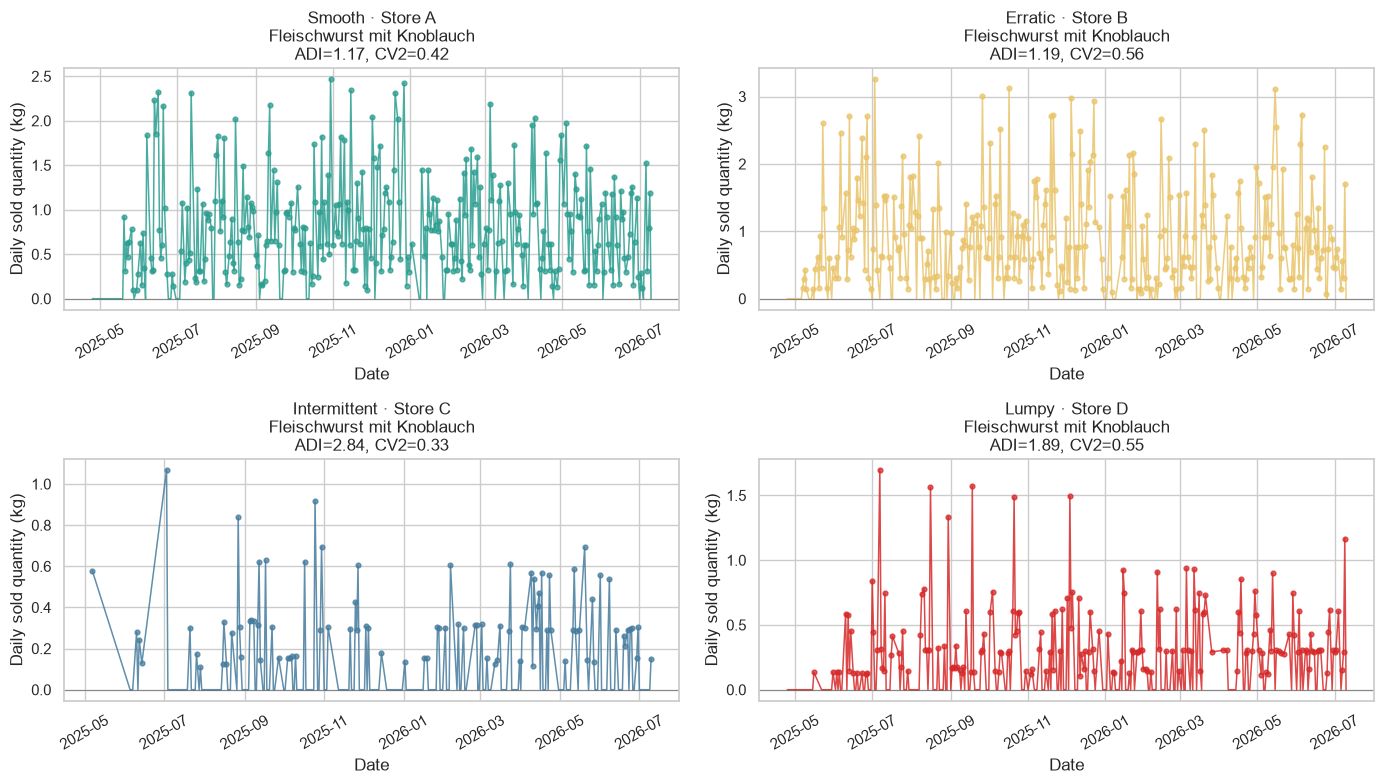

In [30]:
daily_proxy_example_keys = daily_proxy_example_series[
    ["demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID"]
].copy()
con.register("daily_proxy_example_keys", daily_proxy_example_keys)

daily_proxy_examples_query = f"""
SELECT
    k.demand_class,
    k.store_label,
    d.ARTIKEL_ID,
    d.MARKT_ID,
    CAST(d.DATE AS DATE) AS sale_date,
    SUM(CAST(COALESCE(d.{DEMAND_COL}, 0) AS DOUBLE)) AS demand,
    MAX(CAST(COALESCE(d.HAS_POSITIVE_SALE, 0) AS INTEGER)) AS has_positive_sale,
    MIN(d.AVAILABILITY_SOURCE) AS availability_source
FROM read_parquet(?) AS d
JOIN daily_proxy_example_keys AS k
    ON d.ARTIKEL_ID = k.ARTIKEL_ID
    AND d.MARKT_ID = k.MARKT_ID
GROUP BY
    k.demand_class, k.store_label, d.ARTIKEL_ID, d.MARKT_ID, sale_date
ORDER BY k.demand_class, k.store_label, sale_date
"""
daily_proxy_example_ts = con.execute(
    daily_proxy_examples_query, [proxy_glob]
).fetchdf()

daily_proxy_plot_data = daily_proxy_example_ts.merge(
    daily_proxy_example_series[[
        "demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID",
        "ARTIKEL_BEZ", "ARTIKEL_INHALT", "VERKAUFSEINHEIT",
        "ADI", "CV2", "active_days", "demand_days",
    ]],
    on=["demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID"],
    how="left",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.ravel()

for ax, demand_class in zip(axes, CLASS_ORDER):
    subset = daily_proxy_plot_data[
        daily_proxy_plot_data["demand_class"].eq(demand_class)
    ].sort_values("sale_date")
    meta = subset.iloc[0]
    color = CLASS_PALETTE[demand_class]
    positive_subset = subset[subset["demand"] > 0]
    article_name = str(meta["ARTIKEL_BEZ"])
    if len(article_name) > 44:
        article_name = article_name[:41] + "..."

    ax.plot(subset["sale_date"], subset["demand"], color=color, linewidth=1.1, alpha=0.85)
    ax.scatter(
        positive_subset["sale_date"], positive_subset["demand"],
        color=color, s=12, alpha=0.75,
    )
    ax.axhline(0, color="#444444", linewidth=0.8, alpha=0.5)
    ax.set_title(
        f"{demand_class.capitalize()} · {meta['store_label']}\n"
        f"{article_name}\n"
        f"ADI={meta['ADI']:.2f}, CV2={meta['CV2']:.2f}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Daily sold quantity ({meta['VERKAUFSEINHEIT']})")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()


## Interpretation

The availability-proxy view should be read as a sensitivity check, not as ground truth inventory. If many series change class or ADI drops materially, then the daily classification is strongly dependent on whether generated zero-sales days are treated as real no-demand days.

That is the core limitation of daily product-store forecasting here: without reliable availability information, daily zeros mix true no-sale days with days where product availability is uncertain. The replenishment proxy reduces this ambiguity, but it does not remove it completely.
